
# 🚢 Titanic Dataset — ANN Classification

এই notebook-এ Titanic dataset ব্যবহার করে একটি **Artificial Neural Network (ANN)** তৈরি করা হবে।

### কী কী করা হবে?
1. Dataset load ও basic inspection
2. Missing value analysis
3. Feature selection
4. Categorical encoding
5. Train/validation/test split
6. StandardScaler দিয়ে feature scaling
7. ANN model তৈরি
8. EarlyStopping + ModelCheckpoint
9. Training history visualization
10. Accuracy, Precision, Recall, F1-score
11. Confusion Matrix
12. ROC Curve ও AUC
13. নতুন passenger-এর survival prediction


## Cell 1 — প্রয়োজনীয় Library Import
এই cell-এ data processing, visualization এবং ANN তৈরির জন্য প্রয়োজনীয় Python library import করা হচ্ছে।

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("TensorFlow version:", tf.__version__)


c:\Users\Md Emon Islam\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Md Emon Islam\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


TensorFlow version: 2.21.0


## Cell 2 — Dataset Load
Seaborn-এর built-in Titanic dataset ব্যবহার করছি। আলাদা CSV file প্রয়োজন হবে না।

In [2]:

df = sns.load_dataset("titanic")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Cell 3 — Dataset সম্পর্কে ধারণা
`info()`, missing values এবং descriptive statistics দেখে dataset-এর structure বুঝব।

In [3]:

df.info()

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nStatistical summary:")
display(df.describe(include="all").T)


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB

Missing values:


deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64


Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cell 4 — Target ও Feature নির্বাচন
`survived` হবে target variable। এখানে passenger-এর survival prediction করার জন্য age, fare, class, sex, embarkation ইত্যাদি ব্যবহার করা হচ্ছে।

In [4]:

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

target = "survived"

X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())


X shape: (891, 7)
y shape: (891,)


,pclass,sex,age,sibsp,parch,fare,embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## Cell 5 — Train/Test Split
প্রথমে 80% data training এবং 20% testing-এর জন্য রাখা হবে। `stratify=y` ব্যবহার করায় দুই সেটে survived/ not-survived-এর অনুপাত প্রায় একই থাকবে।

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 712
Testing samples : 179


## Cell 6 — Numerical ও Categorical Column নির্ধারণ
Numerical column-এ missing value পূরণ ও scaling করা হবে। Categorical column-এ missing value পূরণ করে One-Hot Encoding করা হবে।

In [6]:

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)


Numerical: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical: ['sex', 'embarked']


## Cell 7 — Preprocessing Pipeline
এখানে data leakage এড়ানোর জন্য preprocessing শুধু training data থেকে শেখানো হবে। Numerical data-তে median imputation + StandardScaler এবং categorical data-তে most-frequent imputation + OneHotEncoder ব্যবহার করা হচ্ছে।

In [7]:

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)


Processed training shape: (712, 10)
Processed testing shape : (179, 10)


## Cell 8 — Validation Set তৈরি
Training data-এর 20% validation হিসেবে রাখা হচ্ছে। ANN training-এর সময় validation performance দেখে overfitting monitor করা হবে।

In [8]:

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train_final.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_processed.shape)


Train: (569, 10)
Validation: (143, 10)
Test: (179, 10)


## Cell 9 — ANN Model তৈরি
এখানে একটি Feed-Forward Neural Network তৈরি করছি।

- Input layer: processed feature সংখ্যা অনুযায়ী
- Dense(64): প্রথম hidden layer
- Dense(32): দ্বিতীয় hidden layer
- Dropout: overfitting কমাতে
- Output Dense(1, sigmoid): binary classification

In [9]:

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_final.shape[1],)),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.20),

    tf.keras.layers.Dense(16, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 192 (768.00 B)

## Cell 10 — Model Compile
Binary classification হওয়ায় `binary_crossentropy` loss এবং `adam` optimizer ব্যবহার করছি।

In [10]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully.")


Model compiled successfully.


## Cell 11 — Callbacks
`EarlyStopping` validation loss উন্নতি না করলে training বন্ধ করবে। `ModelCheckpoint` সবচেয়ে ভালো validation performance-এর model save করবে।

In [11]:

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_titanic_ann.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True
    )
]


## Cell 12 — ANN Training
এই cell-এ ANN training শুরু হবে। `validation_data` দিয়ে প্রতি epoch-এ validation performance দেখা হবে।

In [12]:

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4236 - loss: 1.0448 - precision: 0.3946 - recall: 0.9450 - val_accuracy: 0.5594 - val_loss: 0.6997 - val_precision: 0.4565 - val_recall: 0.7636
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5659 - loss: 0.8193 - precision: 0.4652 - recall: 0.8899 - val_accuracy: 0.6713 - val_loss: 0.6647 - val_precision: 0.6176 - val_recall: 0.3818
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6678 - loss: 0.6653 - precision: 0.5466 - recall: 0.7798 - val_accuracy: 0.6923 - val_loss: 0.6412 - val_precision: 0.6774 - val_recall: 0.3818
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7311 - loss: 0.5785 - precision: 0.6182 - recall: 0.7798 - val_accuracy: 0.6853 - val_loss: 0.6146 - val_precision: 0.7083 - val_recall: 0.3091
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7504 - loss: 0.5369 - precision: 0.6638 - recall: 0.7064 - val_accuracy: 0.7483 - val_loss: 0.5898

## Cell 13 — Training History Visualization
Training ও validation accuracy/loss-এর graph দেখে model underfitting বা overfitting করছে কি না বোঝা যায়।

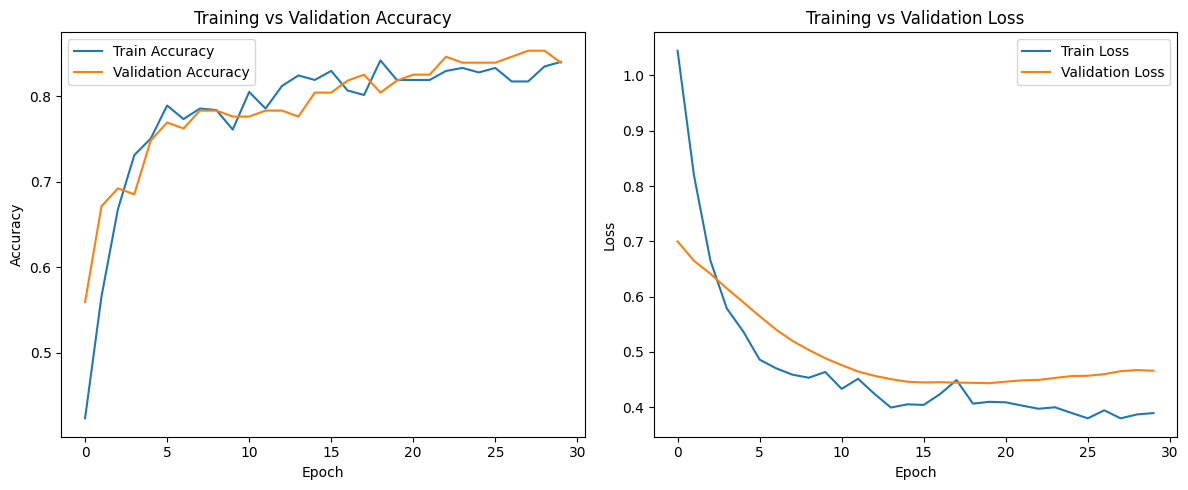

In [13]:

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


## Cell 14 — Test Prediction
Test data-এর জন্য probability এবং final class prediction তৈরি করা হবে।

In [14]:

y_prob = model.predict(X_test_processed, verbose=0).ravel()
y_pred = (y_prob >= 0.50).astype(int)

print("First 10 probabilities:", y_prob[:10])
print("First 10 predictions  :", y_pred[:10])


First 10 probabilities: [0.10447311 0.1708511  0.1791341  0.10939831 0.5293364  0.34534952
 0.85996264 0.35111335 0.6123854  0.21081601]
First 10 predictions  : [0 0 0 0 1 0 1 0 1 0]


## Cell 15 — Classification Metrics
Accuracy-এর পাশাপাশি Precision, Recall এবং F1-score দেখানো হচ্ছে।

In [15]:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Survived", "Survived"],
    zero_division=0
))


Accuracy : 0.7765
Precision: 0.8222
Recall   : 0.5362
F1-score : 0.6491

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.76      0.93      0.84       110
    Survived       0.82      0.54      0.65        69

    accuracy                           0.78       179
   macro avg       0.79      0.73      0.74       179
weighted avg       0.78      0.78      0.76       179



## Cell 16 — Confusion Matrix
Confusion Matrix থেকে True Negative, False Positive, False Negative এবং True Positive দেখা যাবে।

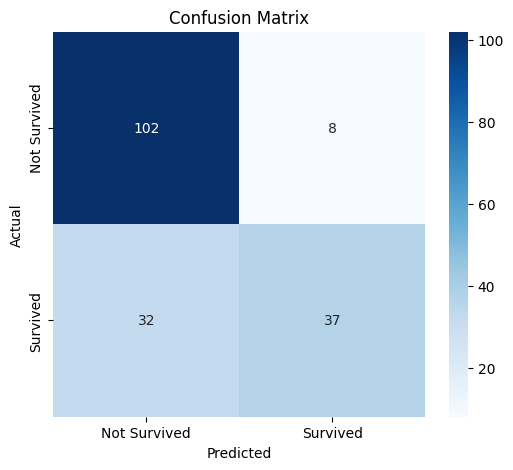

In [16]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Cell 17 — ROC Curve ও AUC
ROC curve বিভিন্ন classification threshold-এ model-এর performance দেখায়। AUC হলো ROC curve-এর নিচের area।

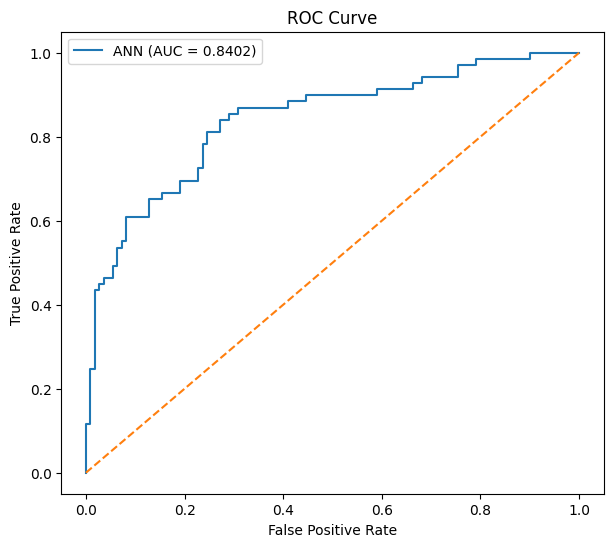

ROC-AUC: 0.8402


In [17]:

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ANN (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")


## Cell 18 — Metrics Comparison Plot
চারটি প্রধান classification metric একসাথে visualization করা হচ্ছে।

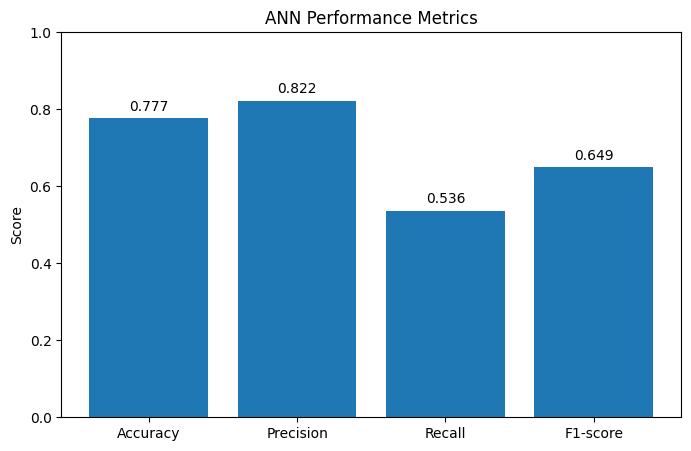

In [18]:

metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("ANN Performance Metrics")

for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.show()


## Cell 19 — Saved Model Load করে Test
Saved `.keras` model ঠিকভাবে load করা যাচ্ছে কি না যাচাই করা হচ্ছে।

In [19]:

best_model = tf.keras.models.load_model("best_titanic_ann.keras")

test_loss, test_accuracy, test_precision, test_recall = best_model.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")


Test Loss      : 0.4834
Test Accuracy  : 0.7989
Test Precision : 0.8235
Test Recall    : 0.6087


## Cell 20 — New Passenger Prediction
একজন নতুন passenger-এর তথ্য দিয়ে ANN survival probability বের করা হবে।

In [20]:

new_passenger = pd.DataFrame([{
    "pclass": 1,
    "sex": "female",
    "age": 25,
    "sibsp": 0,
    "parch": 0,
    "fare": 80.0,
    "embarked": "S"
}])

new_passenger_processed = preprocessor.transform(new_passenger)

survival_probability = best_model.predict(
    new_passenger_processed,
    verbose=0
)[0][0]

prediction = int(survival_probability >= 0.50)

print(f"Survival Probability: {survival_probability:.2%}")
print("Prediction:", "Survived" if prediction == 1 else "Not Survived")


Survival Probability: 99.50%
Prediction: Survived



## ✅ Final Workflow

**Raw Titanic Data**
→ Missing Value Handling
→ One-Hot Encoding
→ StandardScaler
→ Train/Validation/Test Split
→ ANN
→ EarlyStopping + ModelCheckpoint
→ Prediction
→ Accuracy / Precision / Recall / F1
→ Confusion Matrix
→ ROC-AUC
→ Saved Model

### গুরুত্বপূর্ণ
এই notebook-এ preprocessing training data-এর উপর `fit` করা হয়েছে এবং test data-এর উপর শুধু `transform` করা হয়েছে। এতে test-set leakage এড়ানো যায়।
